## NLP - Analisando Commits do Github

### Objetivo:
Treinar um modelo NLP para classificar textos como commits aceitos ou não

In [2]:
import os
import pandas as pd
import time
from datetime import datetime
from dotenv import load_dotenv
from github import Github, Auth
from github.GithubException import RateLimitExceededException, GithubException
from main import extrair_dados_pr, coletar_dados
from typing import List, Dict, Any
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
load_dotenv()

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
if not GITHUB_TOKEN:
    raise ValueError("Token do GitHub não encontrado. Verifique seu arquivo .env")

In [17]:
# Lista de repositórios (ex.: "owner/repo")
REPOSITORIOS_ALVO = [
    "keras-team/keras",
    "pytorch/pytorch",
    "pygame/pygame",
    "tensorflow/tensorflow",
    "microsoft/vscode",
    "pandas-dev/pandas"
]


In [4]:
COLUNAS = [
    "repo", "pr_number", "title", "author", "state", "was_merged",
    "body", "created_at", "closed_at", "merged_at",
    "additions", "deletions", "changed_files", "commits", "comments_count", "review_comments_count"
]

In [21]:
def init_github() -> Github:
    """Inicializa o cliente autenticado do GitHub API v3 usando o método recomendado."""
    token = os.getenv("GITHUB_TOKEN")
    if not token:
        raise ValueError("GITHUB_TOKEN não encontrado no .env")

    auth = Auth.Token(token)
    return Github(auth=auth, per_page=100)


def fetch_commits(
    gh: Github, repo_name: str, max_commits: int = 300
) -> List[Dict[str, Any]]:
    """Coleta commits de um repositório usando a API v3."""
    commits_data = []

    try:
        repo = gh.get_repo(repo_name)
        commits = repo.get_commits()  # isso já retorna um objeto paginado

        for i, commit in enumerate(commits):
            if i >= max_commits:
                break

            commit_info = commit.commit

            author = (
                commit.author.login if commit.author else commit.commit.author.name
            )

            commits_data.append(
                {
                    "repo": repo_name,
                    "sha": commit.sha,
                    "author": author,
                    "date": commit_info.author.date,
                    "message": commit_info.message,
                    "additions": commit.stats.additions,
                    "deletions": commit.stats.deletions,
                    "total_changes": commit.stats.total,
                    "url": commit.html_url,
                }
            )

    except RateLimitExceededException:
        print("⚠️ Rate limit atingido! Aguardando 60 segundos...")
        time.sleep(60)
        return fetch_commits(gh, repo_name, max_commits)

    except GithubException as e:
        print(f"Erro ao acessar {repo_name}: {e}")

    return commits_data


def collect_commits_from_multiple_repos(
    repos: List[str], max_commits_repo: int = 300
) -> pd.DataFrame:
    """Coleta commits de vários repositórios e retorna como DataFrame."""
    gh = init_github()
    all_commits = []

    for repo in repos:
        print(f"🔍 Coletando commits de: {repo}")
        commits_data = fetch_commits(gh, repo, max_commits_repo)
        all_commits.extend(commits_data)

    df = pd.DataFrame(all_commits)
    df["date"] = pd.to_datetime(df["date"])

    return df

In [22]:
init_github()

df = collect_commits_from_multiple_repos(REPOSITORIOS_ALVO, max_commits_repo=300)

🔍 Coletando commits de: keras-team/keras
🔍 Coletando commits de: pytorch/pytorch
🔍 Coletando commits de: pygame/pygame
🔍 Coletando commits de: tensorflow/tensorflow
🔍 Coletando commits de: microsoft/vscode
🔍 Coletando commits de: pandas-dev/pandas


In [23]:
df

,repo,sha,author,date,message,additions,deletions,total_changes,url
0,keras-team/keras,032528babea6ba938676375e488604d9ddcf00cd,SamareshSingh,2025-11-14 15:22:00+00:00,Fix name_scope_stack AttributeError and IndexE...,87,1,88,https://github.com/keras-team/keras/commit/032...
1,keras-team/keras,39c475b776ea08839bf30abdd918330da95c582c,Abhinavexists,2025-11-14 09:39:11+00:00,Fix typo in variable name 'embeding' to 'embed...,3,3,6,https://github.com/keras-team/keras/commit/39c...
2,keras-team/keras,2730d5214f6804358f667f2ef5ad76e704a08a1b,kharshith-k,2025-11-13 19:32:36+00:00,Run tests on TPU (#21425)\n\n* added requireme...,341,2,343,https://github.com/keras-team/keras/commit/273...
3,keras-team/keras,bfde12b2671478bd4e2939af646ffc62589ffa04,shashaka,2025-11-11 23:41:11+00:00,Implement empty_like function in keras.ops (#2...,98,0,98,https://github.com/keras-team/keras/commit/bfd...
4,keras-team/keras,4d30a7f488d47aebec582e4db9331409df246909,hertschuh,2025-11-10 23:20:55+00:00,Fix failing sklearn tests following release of...,4,0,4,https://github.com/keras-team/keras/commit/4d3...
...,...,...,...,...,...,...,...,...,...
1795,pandas-dev/pandas,2b25842701346c18d307751ea36ade71caaf3792,jorisvandenbossche,2025-09-21 13:38:20+00:00,String dtype: keep select_dtypes(include=objec...,31,13,44,https://github.com/pandas-dev/pandas/commit/2b...
1796,pandas-dev/pandas,e81793073a6782490c8dd02f2f4ab42c102904d6,EvMossan,2025-09-21 07:27:05+00:00,CI: add PyPI Trusted-Publishing “publish” job ...,45,3,48,https://github.com/pandas-dev/pandas/commit/e8...
1797,pandas-dev/pandas,10a53051e74d2fec2131c4daa6c6a234c98e4dab,jarent-nvidia,2025-09-19 18:34:53+00:00,TST: test that re-using a list of groupers wil...,16,0,16,https://github.com/pandas-dev/pandas/commit/10...
1798,pandas-dev/pandas,4ffdfe940c2bb913e83ad4d3aa3b270d03fdb8a8,AnandMukherjee2004,2025-09-19 16:44:11+00:00,DOC: Clarify parentheses vs. brackets usage (G...,2,1,3,https://github.com/pandas-dev/pandas/commit/4f...


In [25]:
df.message[100]

'Add _post_quantize to fix torch_params not releasing issue. (#21654)'

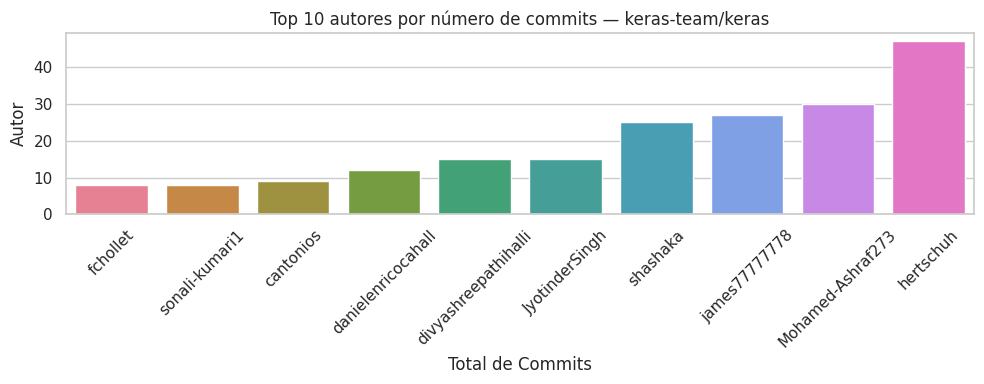

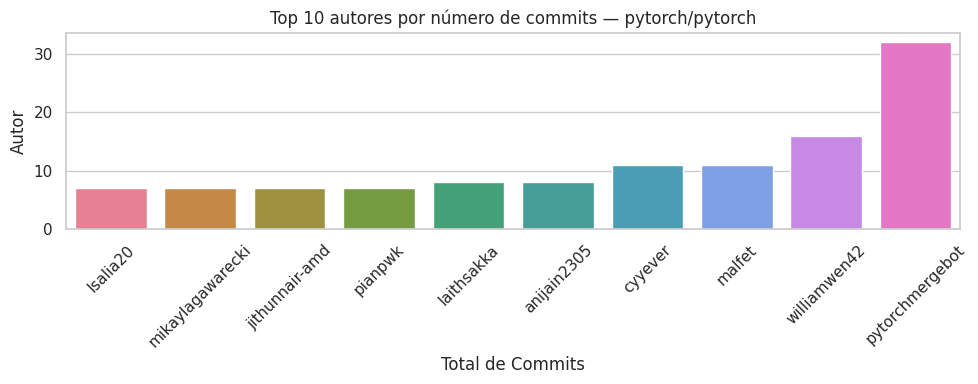

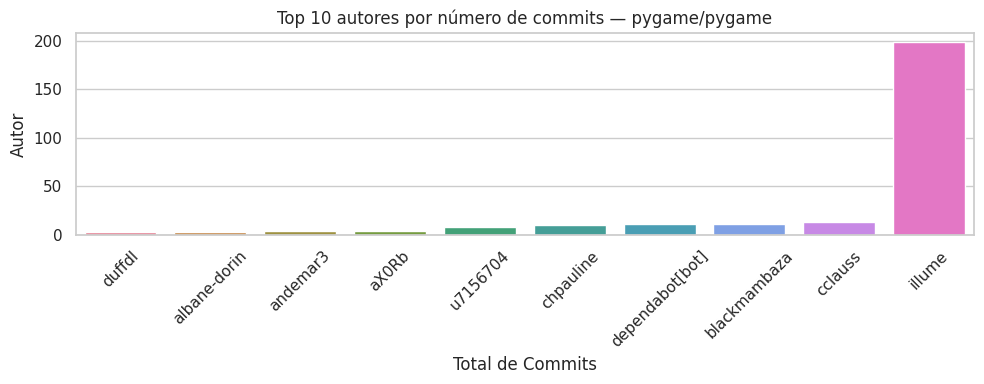

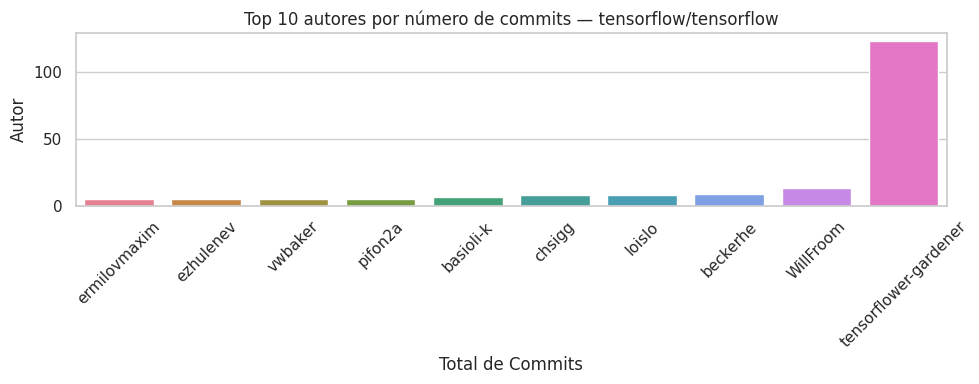

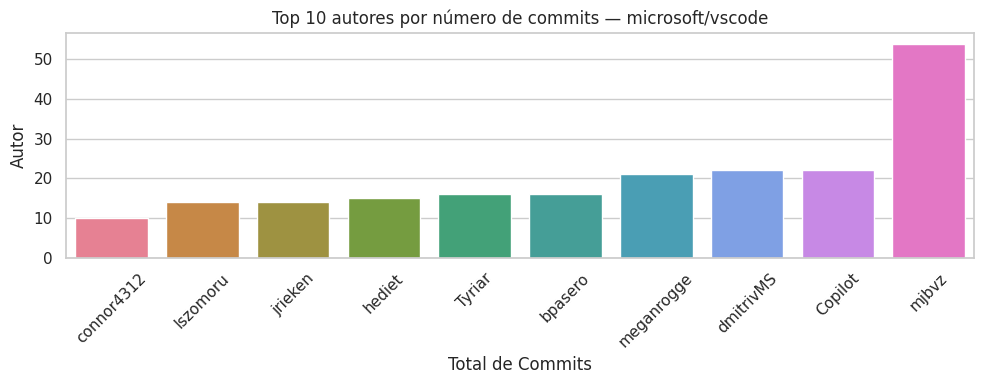

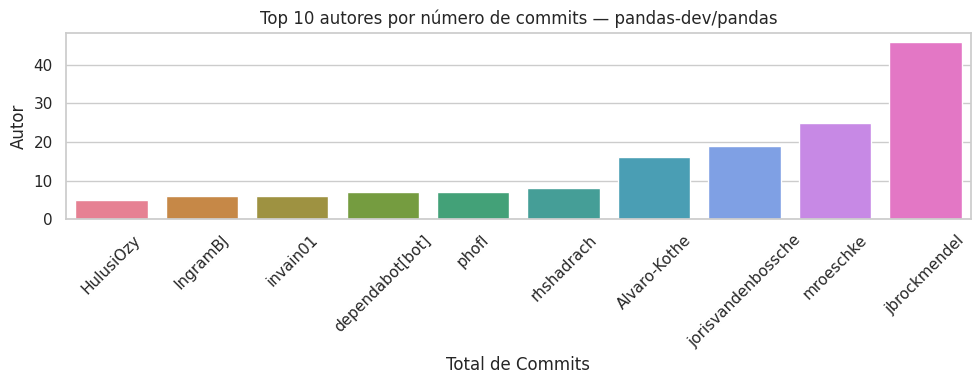

In [44]:
# Garante estilo bonito
sns.set_style("whitegrid")
sns.set_palette("viridis")

# Loop por repositório
for repo in df["repo"].unique():
    df_repo = df[df["repo"] == repo]

    # Contar commits por autor
    top = (
        df_repo.groupby("author")
        .size()
        .reset_index(name="total_commits")
        .sort_values("total_commits", ascending=False)
        .head(10)
    )

    if top.empty:
        continue

    # Ordenar para gráfico horizontal (menor em cima)
    top = top.sort_values("total_commits", ascending=True)

    plt.figure(figsize=(10, max(4, 0.4 * len(top))))
    sns.barplot(
        x="author", 
        y="total_commits", 
        data=top,
        hue="author"
    )

    plt.title(f"Top 10 autores por número de commits — {repo}")
    plt.xlabel("Total de Commits")
    plt.xticks(rotation=45)
    plt.ylabel("Autor")
    plt.tight_layout()
    plt.show()


In [45]:
df.to_csv("backup_commits_enzo.csv", index=False)

In [5]:
df = pd.read_csv("backup_commits_enzo.csv")

In [6]:
df_treino = pd.DataFrame()

df_treino["text"] = df.message

In [7]:
df_treino["label"] = 1

df_treino["repo"] = df.repo 

In [8]:
df_treino

,text,label,repo
0,Fix name_scope_stack AttributeError and IndexE...,1,keras-team/keras
1,Fix typo in variable name 'embeding' to 'embed...,1,keras-team/keras
2,Run tests on TPU (#21425)\n\n* added requireme...,1,keras-team/keras
3,Implement empty_like function in keras.ops (#2...,1,keras-team/keras
4,Fix failing sklearn tests following release of...,1,keras-team/keras
...,...,...,...
1795,String dtype: keep select_dtypes(include=objec...,1,pandas-dev/pandas
1796,CI: add PyPI Trusted-Publishing “publish” job ...,1,pandas-dev/pandas
1797,TST: test that re-using a list of groupers wil...,1,pandas-dev/pandas
1798,DOC: Clarify parentheses vs. brackets usage (G...,1,pandas-dev/pandas


In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samuelkamau/2021-covid19-x-tweets")

print("Path to dataset files:", path)

/home/enzof/projects/NLP/Pull-request-analyzer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 75.7k/75.7k [00:00<00:00, 595kB/s]

Extracting files...
Path to dataset files: /home/enzof/.cache/kagglehub/datasets/samuelkamau/2021-covid19-x-tweets/versions/1


In [10]:
df_x = pd.read_csv("./2021-covid19-x-tweets/versions/1/Simba_tweets.csv")

In [11]:
df_x

,Unnamed: 0,tweet_id_str,date_time,location,tweet_text
0,0,1465539276729470976,2021-11-30 04:32:46,Ethereum,"sad , reality live ... #vaccinemandate #pfizer..."
1,1,1465538501257093124,2021-11-30 04:29:41,"Charlotte, NC",many sad stories like one !
2,2,1465536814685507596,2021-11-30 04:22:59,"Boston, MA",slow suicide
3,3,1465536791822303235,2021-11-30 04:22:54,Nazi free USA,nazi scum profiting hospitalizations deaths ga...
4,4,1465536577875197957,2021-11-30 04:22:03,"Pennsylvania, USA",people literally anything avoid admitting effe...
...,...,...,...,...,...
995,995,1465023563342176267,2021-11-28 18:23:30,NY,im really happy bts able see army person im ki...
996,996,1465022784304660481,2021-11-28 18:20:25,USA,"omg , picture #sdcc2021 sad. fuck covid."
997,997,1465021526940557315,2021-11-28 18:15:25,Palliser Triangle,"havent sad gasps air , since upset without cha..."
998,998,1465021466437685248,2021-11-28 18:15:11,"Houston, TX",dad best man passed away suddenly unexpectedly...


In [12]:
df_x["label"] = 0
df_x["origin"] = "X"

In [13]:
df_final = pd.DataFrame()

df_final["text"] = pd.concat([df_treino["text"], df_x["tweet_text"]], ignore_index=True)
df_final["label"] = pd.concat([df_treino["label"], df_x["label"]], ignore_index=True)
df_final["origin"] = pd.concat([df_treino["repo"], df_x["origin"]], ignore_index=True)


In [14]:
df_final

,text,label,origin
0,Fix name_scope_stack AttributeError and IndexE...,1,keras-team/keras
1,Fix typo in variable name 'embeding' to 'embed...,1,keras-team/keras
2,Run tests on TPU (#21425)\n\n* added requireme...,1,keras-team/keras
3,Implement empty_like function in keras.ops (#2...,1,keras-team/keras
4,Fix failing sklearn tests following release of...,1,keras-team/keras
...,...,...,...
2795,im really happy bts able see army person im ki...,0,X
2796,"omg , picture #sdcc2021 sad. fuck covid.",0,X
2797,"havent sad gasps air , since upset without cha...",0,X
2798,dad best man passed away suddenly unexpectedly...,0,X


In [15]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_final, test_size=0.2, random_state=42, stratify=df_final["label"])

In [16]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from torch import device
import pandas as pd

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("🔥 Usando dispositivo:", device)
print("GPUs disponíveis:", torch.cuda.device_count())

if torch.cuda.device_count() > 1:
    print("🚀 Treinamento Multi-GPU ativado via DataParallel")


🔥 Usando dispositivo: cuda
GPUs disponíveis: 1


In [18]:
class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes, freeze_bert=False):
        super().__init__()
        self.bert = bert_model
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = outputs.last_hidden_state[:, 0, :]  # Use the CLS token's output
        logits = self.classifier(cls_token)
        return logits

In [19]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings = tokenizer(list(df_train['text']), truncation=True, padding=True, return_tensors='pt')

In [20]:
train_labels = torch.tensor(df_train['label'].tolist())


In [21]:
train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], train_labels)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert = DistilBertModel.from_pretrained("distilbert-base-uncased").to(device)


In [22]:

model = BertClassifier(bert_model=bert, num_classes=2, freeze_bert=False).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)



In [23]:

def train(model, train_loader, optimizer, device):
    model.train()
    epoch_loss = 0
    for batch in tqdm(train_loader):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(train_loader)


In [24]:
all_losses = []
for epoch in range(10):  # Train for some epochs...
    print(f"Epoch {epoch + 1}")
    loss = train(model, train_loader, optimizer, device)
    all_losses.append(loss)

torch.save(model.state_dict(), "distilbert.pth")

Epoch 1


100%|██████████| 560/560 [04:13<00:00,  2.21it/s]


Epoch 2


100%|██████████| 560/560 [06:13<00:00,  1.50it/s]


Epoch 3


...

100%|██████████| 560/560 [05:26<00:00,  1.72it/s]


Epoch 9


100%|██████████| 560/560 [05:30<00:00,  1.70it/s]


Epoch 10


100%|██████████| 560/560 [05:19<00:00,  1.75it/s]


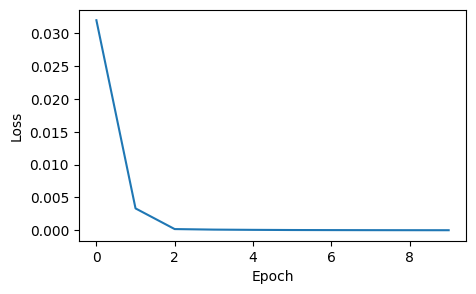

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3))
plt.plot(all_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.savefig(f"distillbert_finetuning.pdf", bbox_inches='tight')
plt.show()

## Testando o modelo treinado

In [26]:
model.load_state_dict(torch.load("distilbert.pth"))

<All keys matched successfully>

In [27]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
test_encodings = tokenizer(list(df_test['text']), truncation=True, padding=True, return_tensors='pt')
test_labels = torch.tensor(df_test['label'].tolist())
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_labels)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [28]:

model.eval()
all_predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids, attention_mask, labels_batch = [x.to(device) for x in batch]
        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)
        all_predictions.append(preds.cpu())

all_predictions = torch.cat(all_predictions)

100%|██████████| 140/140 [00:06<00:00, 21.47it/s]


In [29]:
from sklearn.metrics import classification_report

# Assuming all_predictions and test_labels are defined
print(classification_report(test_labels, all_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       360

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560



In [30]:
import numpy as np

y_pred = all_predictions.numpy()
y_true = df_test["label"].values


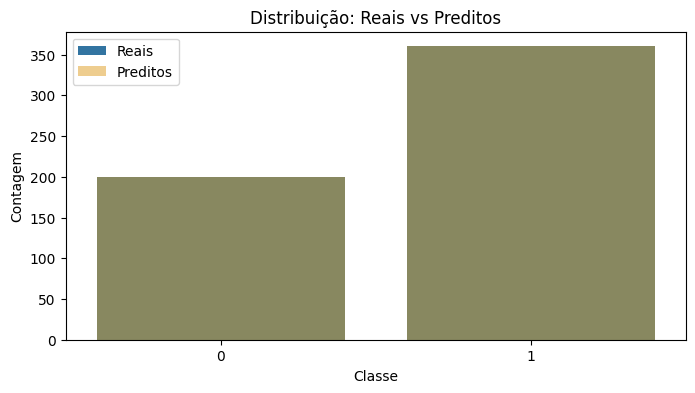

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.countplot(x=y_true, label="Reais")
sns.countplot(x=y_pred, label="Preditos", color="orange", alpha=0.5)

plt.title("Distribuição: Reais vs Preditos")
plt.legend(["Reais", "Preditos"])
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show()


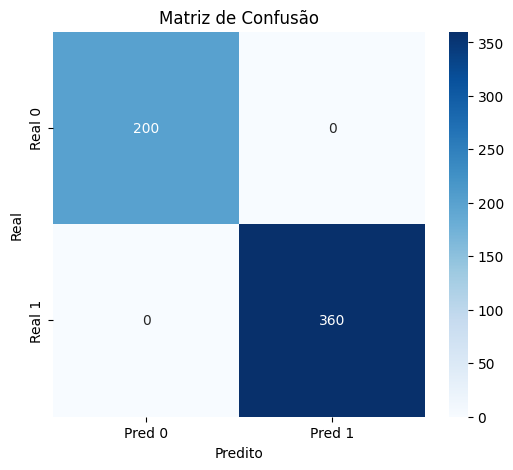

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


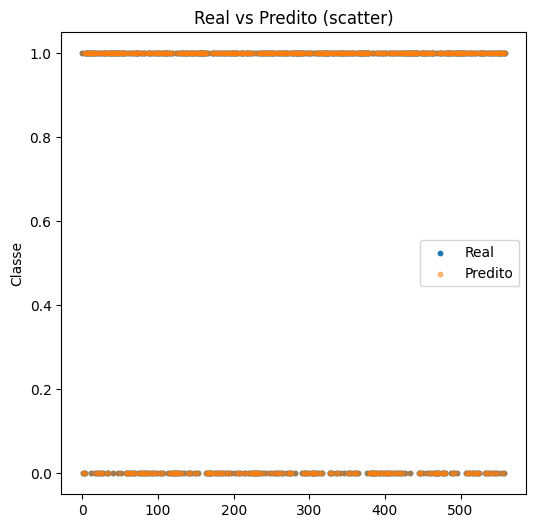

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(range(len(y_true)), y_true, s=10, label="Real")
plt.scatter(range(len(y_pred)), y_pred, s=10, label="Predito", alpha=0.5)

plt.title("Real vs Predito (scatter)")
plt.ylabel("Classe")
plt.legend()
plt.show()
